загрузка и осмотр данных

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('titanic.csv')

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.isna()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


датасет: titanic
строк: 891
столбцов: 12
пропуски: 1. cabin; 2. age; 3. embarked

фильтрация, группировка, простые признаки

In [8]:
df_adult = df[df['Age'] > 18]
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [10]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df[['Survived', 'Pclass', 'Age', 'Fare', 'FamilySize']].corr()

,Survived,Pclass,Age,Fare,FamilySize
Survived,1.000000,-0.338481,-0.077221,0.257307,0.016639
Pclass,-0.338481,1.000000,-0.369226,-0.549500,0.065997
Age,-0.077221,-0.369226,1.000000,0.096067,-0.301914
Fare,0.257307,-0.549500,0.096067,1.000000,0.217138
FamilySize,0.016639,0.065997,-0.301914,0.217138,1.000000


выживаемость сильно зависит от класса (чем выше класс, тем больше выживаемость)
поля класс и цена билета сильно связаны, можно сделать из них один признак

In [11]:
def family_cat(size):
    if size == 1: return 1
    elif 1 < size <= 3: return 2
    else: return 3
df['FamilyCat'] = df['FamilySize'].apply(family_cat)
df.groupby('FamilyCat')['Survived'].mean()

FamilyCat
1    0.303538
2    0.562738
3    0.340659
Name: Survived, dtype: float64

выживаемость выше среди маленьких семей (от 2 до 3 человек)

In [12]:
def age_cat(age):
    if 1 <= age <= 17: return 1
    elif 18 <= age <= 25: return 2
    elif 26 <= age <= 60: return 3
    else: return 4
df['AgeCat'] = df['Age'].apply(age_cat)
df.groupby('AgeCat')['Survived'].mean()

AgeCat
1    0.509434
2    0.335106
3    0.411765
4    0.310680
Name: Survived, dtype: float64

выживаемость выше среди детей и взрослых, наименьшая - среди стариков

In [13]:
df[['Survived', 'Pclass', 'FamilyCat', 'AgeCat']].corr()

,Survived,Pclass,FamilyCat,AgeCat
Survived,1.000000,-0.338481,0.134197,-0.080470
Pclass,-0.338481,1.000000,-0.054495,-0.079348
FamilyCat,0.134197,-0.054495,1.000000,-0.278593
AgeCat,-0.080470,-0.079348,-0.278593,1.000000


однако класс билета остается наиболее предсказательным

обработка пропусков, кодирование категорий

In [20]:
df_orig = df.copy()
df.groupby(['Sex', 'Pclass'])['Age'].median()

Sex     Pclass
female  1         35.0
        2         28.0
        3         21.5
male    1         40.0
        2         30.0
        3         25.0
Name: Age, dtype: float64

In [ ]:
# заполняем пропуски в age медианой по полям sex и pclass, т.к. возраст часто зависит от пола и класса
median_age = df.groupby(['Sex', 'Pclass'])['Age'].transform('median')
df['Age'] = df['Age'].fillna(median_age)
# заполняем пропуски в embarked модой, т.к. пропусков очень мало (2)
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(mode_embarked)


категориальный признак -> числовой

In [ ]:
df['Sex_enc'] = df['Sex'].map({'male': 0, 'female': 1})
# женщинам присваиваем 1, тк среди них выживаемость выше, что будет удобно при использовании логистической регрессии

визуализация

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

Text(0.5, 1.0, 'Выживаемость по полу')

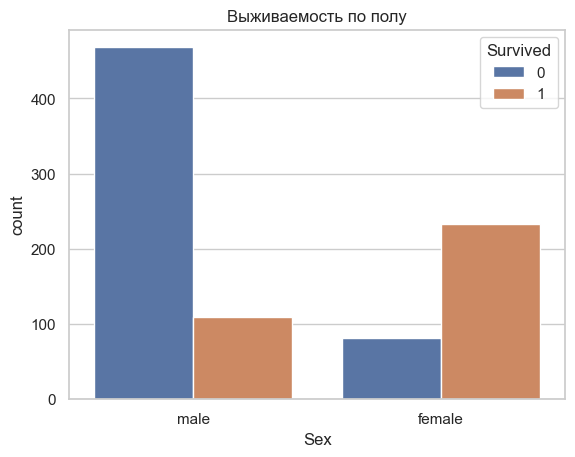

In [ ]:
# график выживаемости по гендерному признаку
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Выживаемость по полу')

Text(0.5, 1.0, 'Разброс цен по классам')

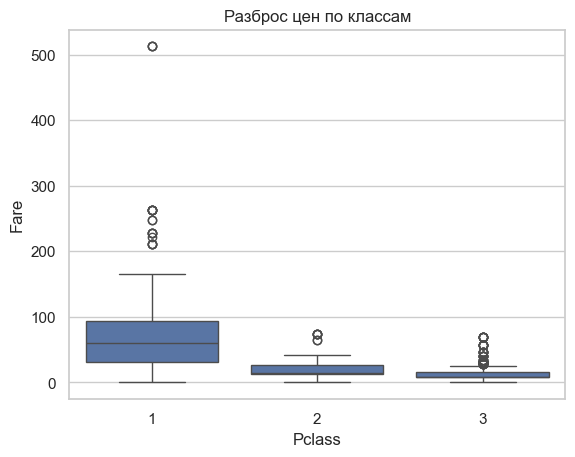

In [30]:
# график разброса цен по классам
sns.boxplot(x='Pclass', y='Fare', data=df)
plt.title('Разброс цен по классам')

Text(0.5, 1.0, 'Распределение возраста')

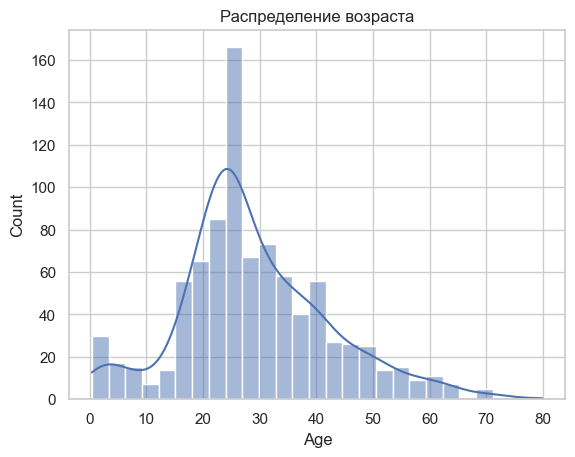

In [31]:
# график распределения возраста
sns.histplot(df['Age'], kde=True)
plt.title('Распределение возраста')

итоги: женщины выживали чаще, стоимость билетов 1 класса выше и имеет больший разброс, распределение возраста неоднородно - пик среди молодежи и молодых взрослых людей. гипотезы корреляционного анализа подтверждены